Dataset shape after cleaning: (1257, 25)


FEATURE ENGINEERING
✓ Created mental_health_risk score (0-6): mean=2.50
✓ Created company_support score (0-4): mean=1.05

✓ Label encoding complete
Dataset shape after encoding: (1257, 26)

Numerical features: 3
Categorical features: 23


1. K-MEANS CLUSTERING (IMPROVED FOR MIXED DATA)
After One-Hot Encoding: 52 features

Finding optimal K using Elbow Method and Silhouette Score...


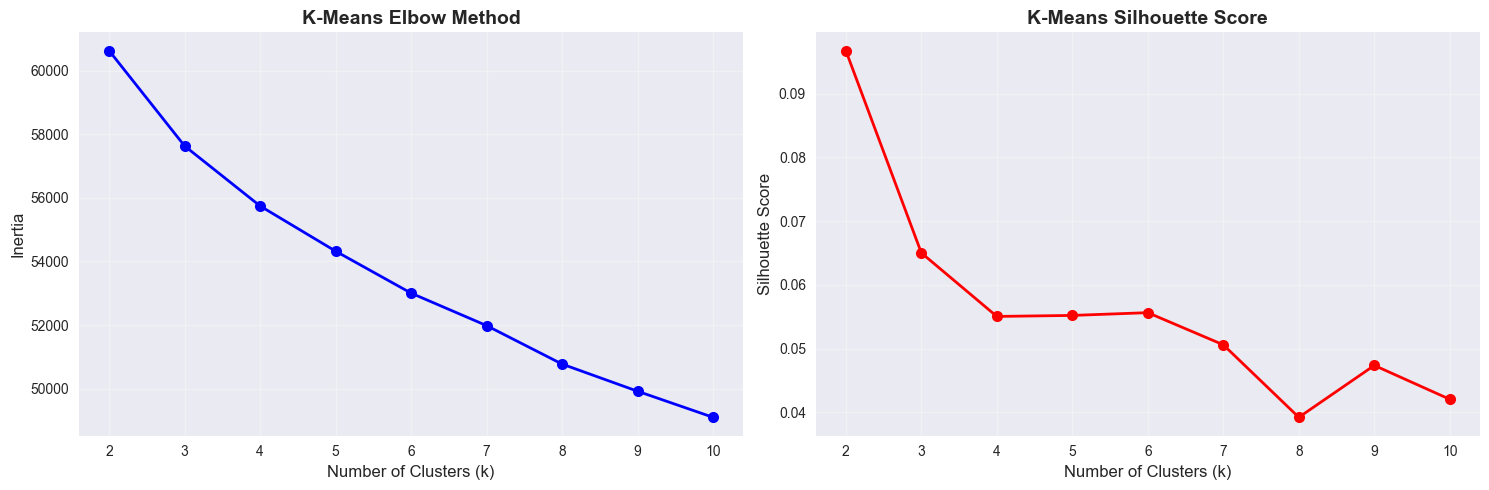


FINAL K-MEANS MODEL: 4 Clusters
Silhouette Score: 0.0550
Davies-Bouldin Index: 3.2332 (lower is better)
Calinski-Harabasz Index: 72.0872 (higher is better)


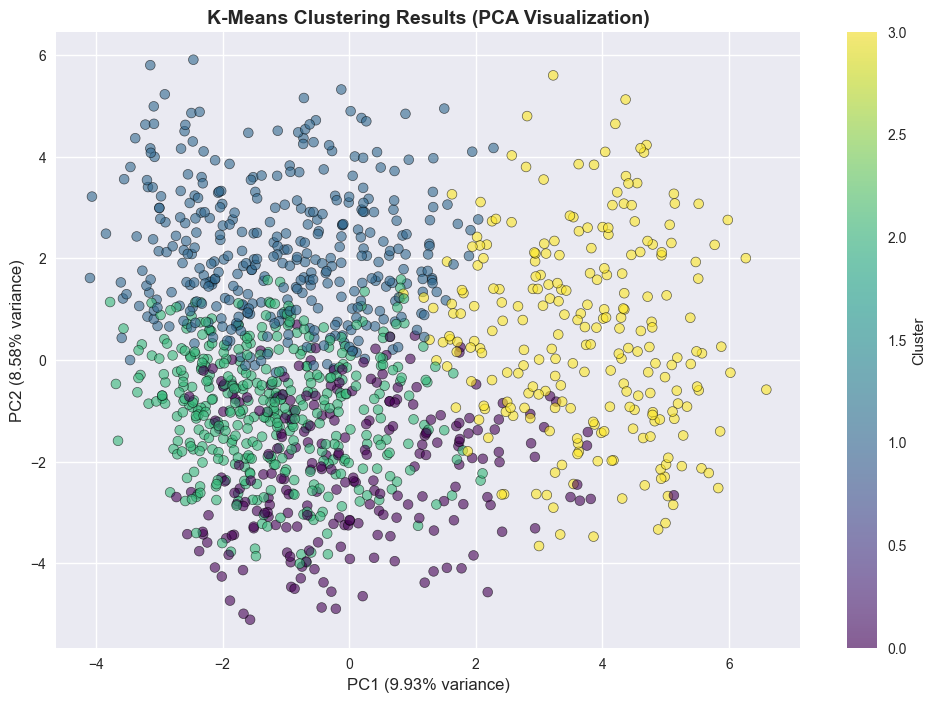


Cluster Distribution:
  Cluster 0: 234 employees (18.6%)
  Cluster 1: 368 employees (29.3%)
  Cluster 2: 413 employees (32.9%)
  Cluster 3: 242 employees (19.3%)


2. K-MODES CLUSTERING (OPTIMIZED FOR CATEGORICAL DATA)

Finding optimal K using Elbow Method...


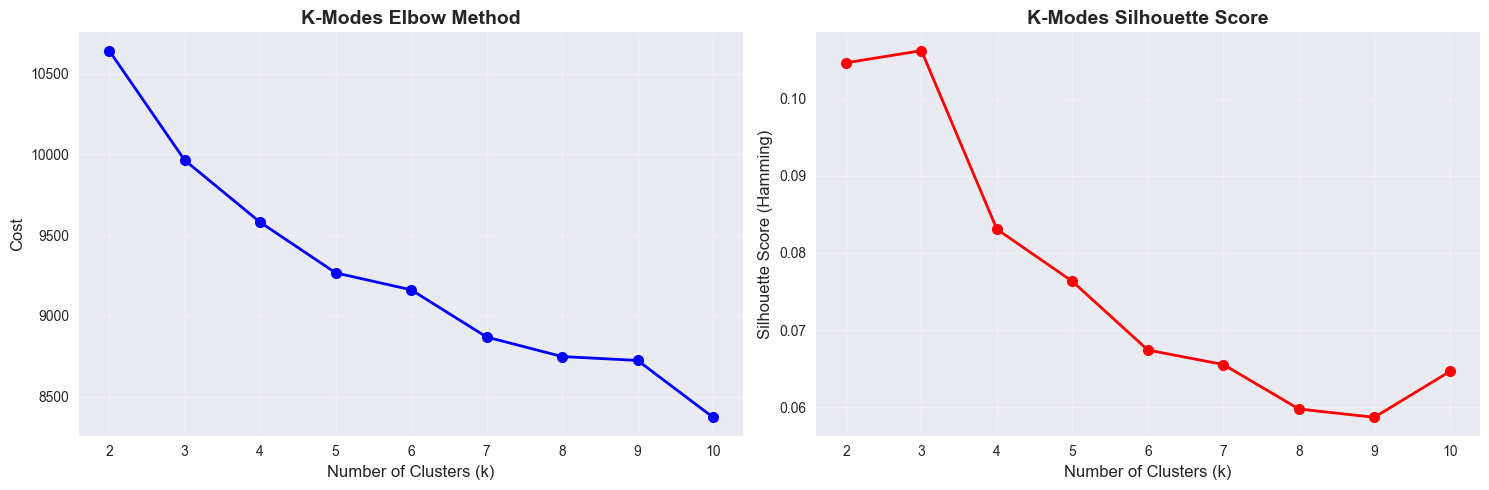


FINAL K-MODES MODEL: 4 Clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 346, cost: 9844.0
Run 1, iteration: 2/100, moves: 27, cost: 9844.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 409, cost: 10232.0
Run 2, iteration: 2/100, moves: 255, cost: 10038.0
Run 2, iteration: 3/100, moves: 214, cost: 9810.0
Run 2, iteration: 4/100, moves: 141, cost: 9810.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 364, cost: 9673.0
Run 3, iteration: 2/100, moves: 132, cost: 9580.0
Run 3, iteration: 3/100, moves: 67, cost: 9580.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 311, cost: 10053.0
Run 4, iteration: 2/100, moves: 100, cost: 9942.0
Run 4, iteration: 3/100, moves: 86, cost: 9883.0
Run 4, iteration: 4/100, moves: 57, cost: 9853.

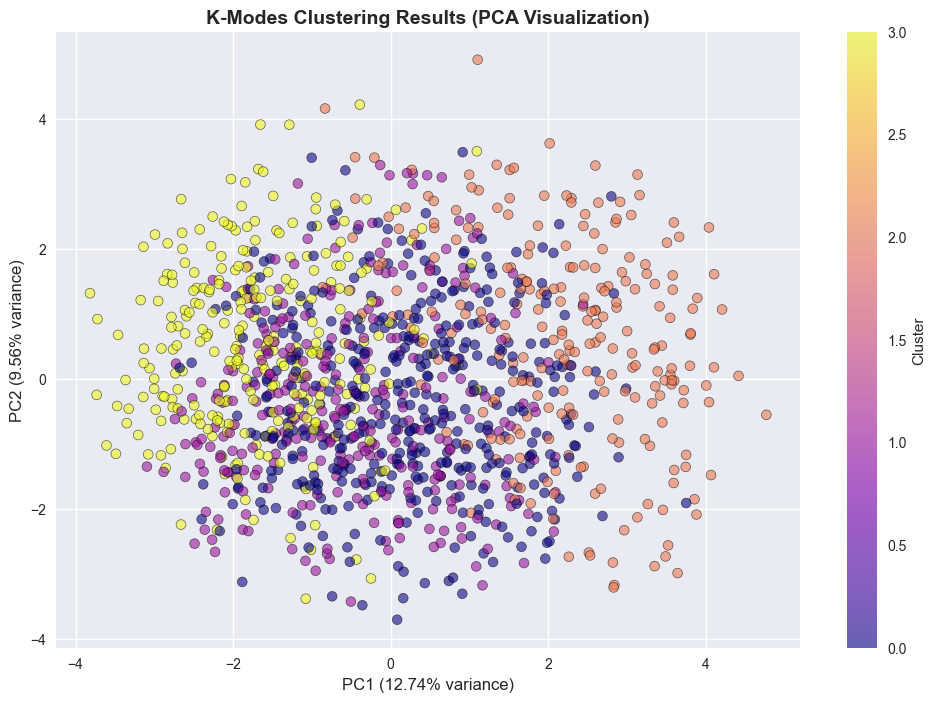


Cluster Distribution:
  Cluster 0: 420 employees (33.4%)
  Cluster 1: 324 employees (25.8%)
  Cluster 2: 243 employees (19.3%)
  Cluster 3: 270 employees (21.5%)


3. DBSCAN CLUSTERING (DENSITY-BASED APPROACH)


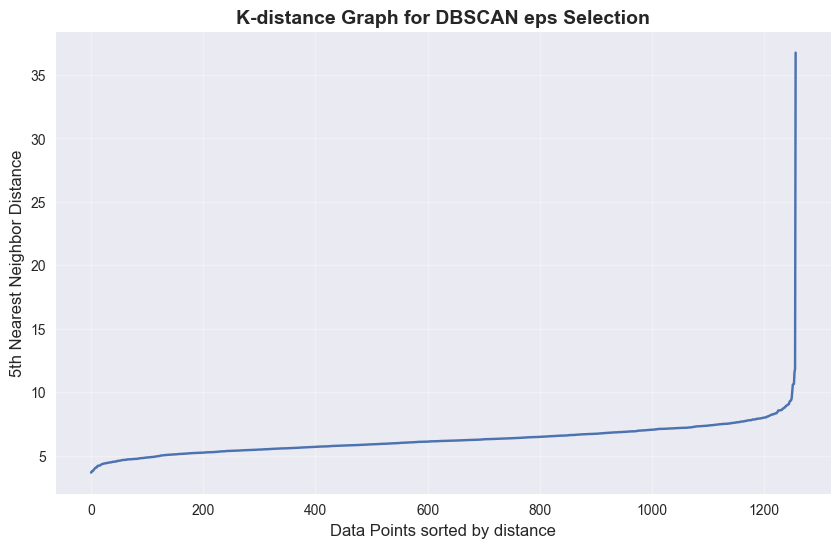


DBSCAN Parameters: eps=3.5, min_samples=5
Number of clusters: 0
Number of noise points: 1257 (100.0%)


4. DETAILED CLUSTER PROFILING

K-MEANS CLUSTER CHARACTERISTICS

CLUSTER 0: 234 employees (18.6%)
  Demographics:
    • Average Age: 31.3 years
    • Remote Work: 40.2%
    • Tech Company: 91.5%

  Mental Health Status:
    • Treatment Rate: 55.1%
    • Family History: 44.0%
    • Work Interference: 52.6%
    • Risk Score: 2.52/6

  Company Support:
    • Benefits: 26.9%
    • Wellness Program: 8.5%
    • Help Resources: 11.1%
    • Support Score: 0.91/4

CLUSTER 1: 368 employees (29.3%)
  Demographics:
    • Average Age: 31.7 years
    • Remote Work: 31.0%
    • Tech Company: 81.5%

  Mental Health Status:
    • Treatment Rate: 83.7%
    • Family History: 58.7%
    • Work Interference: 80.7%
    • Risk Score: 4.18/6

  Company Support:
    • Benefits: 34.5%
    • Wellness Program: 2.7%
    • Help Resources: 3.5%
    • Support Score: 0.59/4

CLUSTER 2: 413 employees (32.9%)
  Demogra

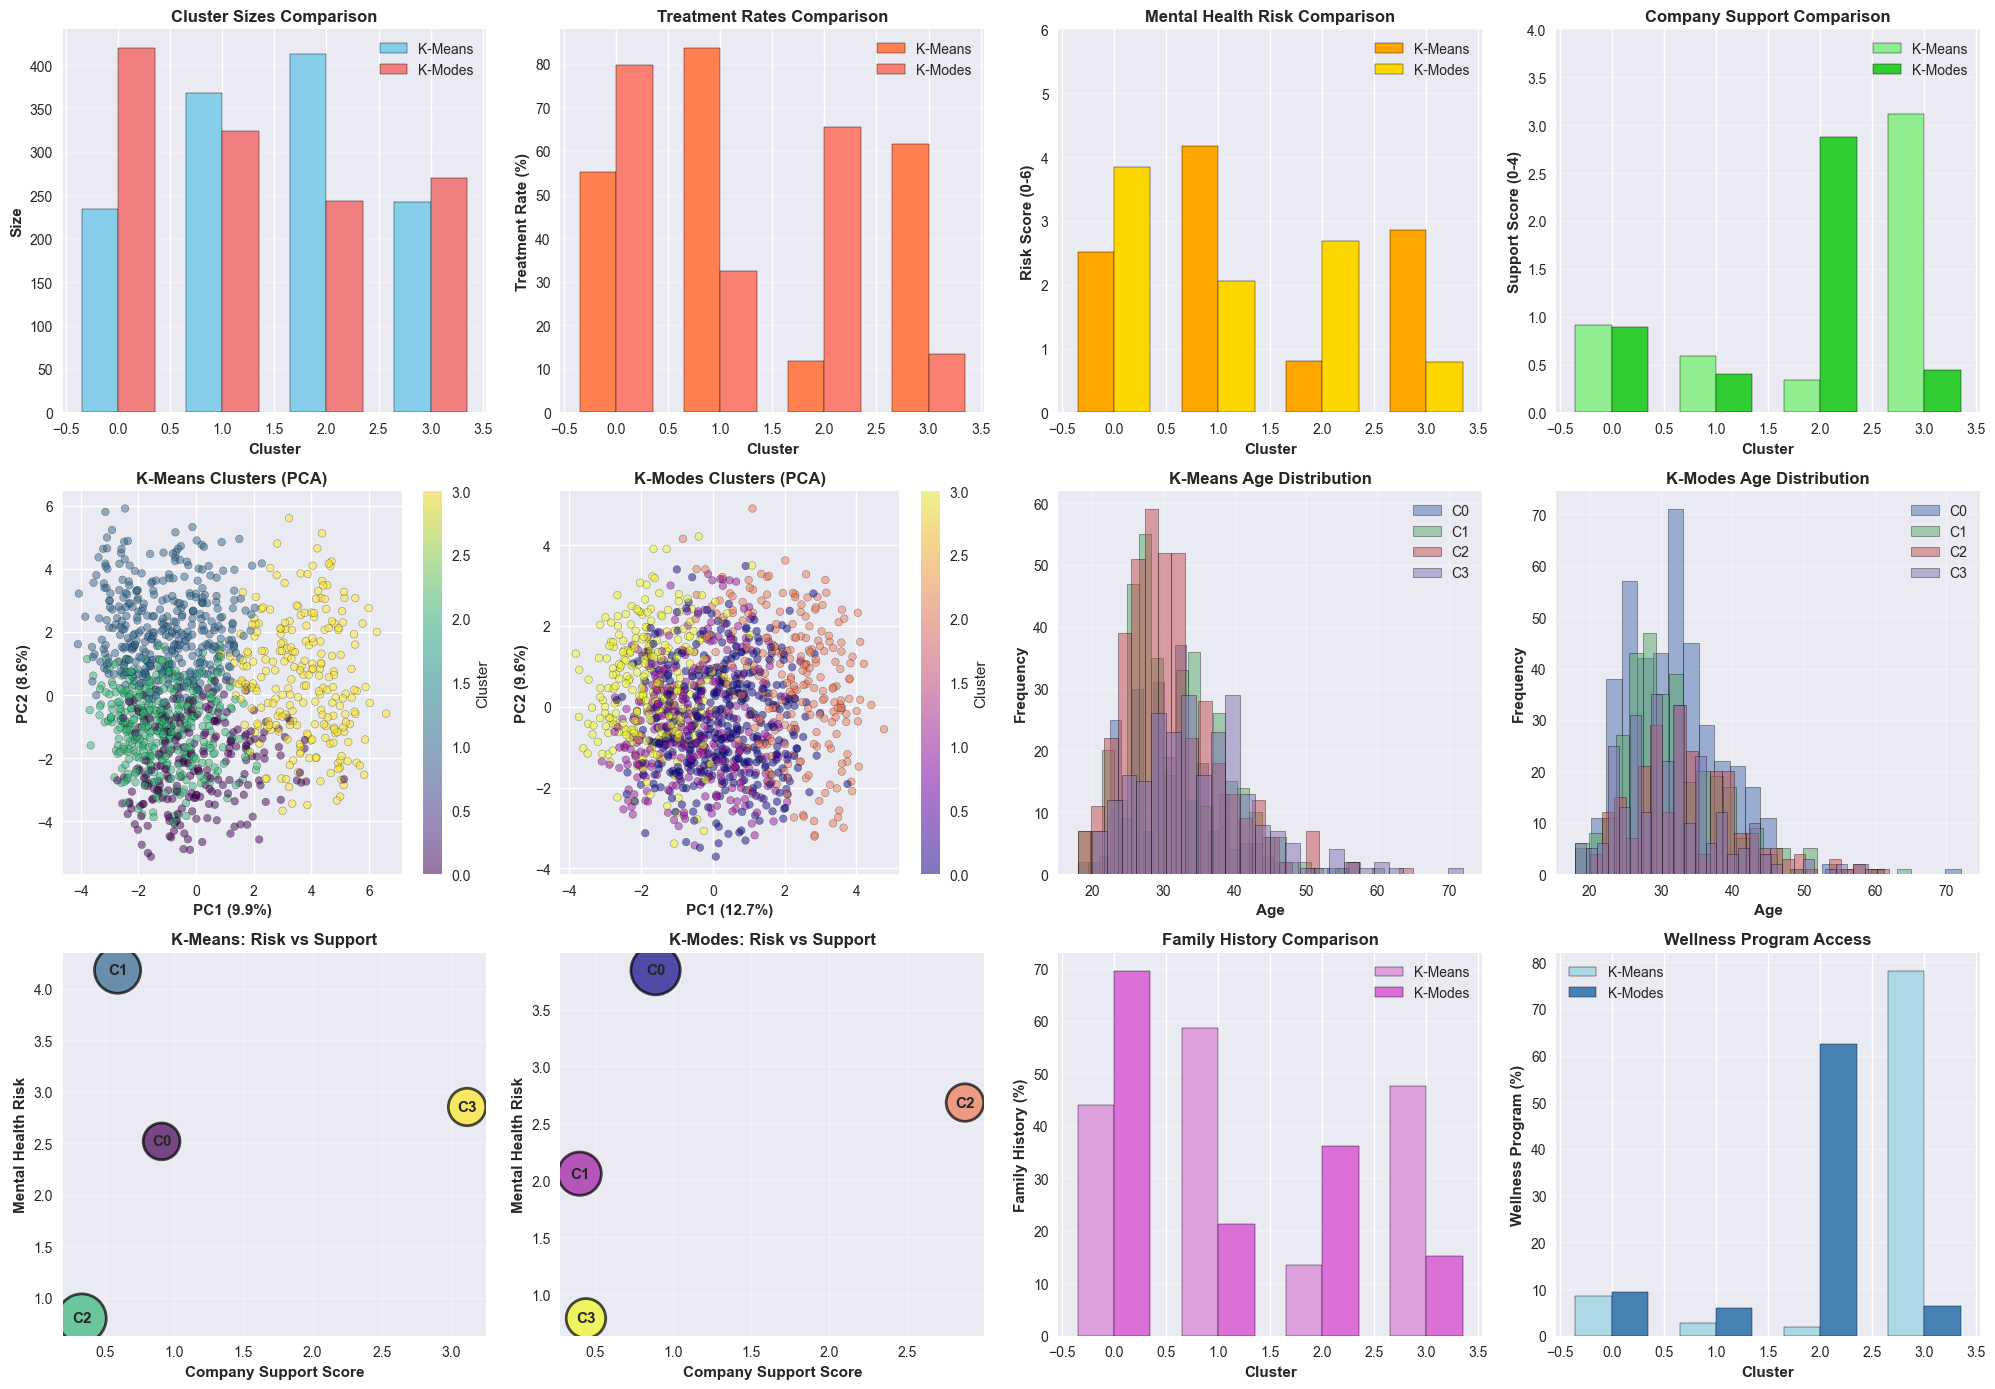



ALGORITHM COMPARISON

            Metric   K-Means   K-Modes
 Silhouette Score  0.055046  0.083079
   Davies-Bouldin  3.233212       N/A
Calinski-Harabasz 72.087207       N/A


Interpretation:
• Silhouette Score (higher is better, -1 to 1):
  - K-Means: 0.0550
  - K-Modes: 0.0831

• Davies-Bouldin Index (lower is better):
  - K-Means: 3.2332

• Calinski-Harabasz Index (higher is better):
  - K-Means: 72.09

STATISTICAL SIGNIFICANCE TESTS

TREATMENT:
  K-Means - Chi2: 422.72, p-value: 0.0000 ✓ SIGNIFICANT
  K-Modes - Chi2: 357.17, p-value: 0.0000 ✓ SIGNIFICANT

FAMILY_HISTORY:
  K-Means - Chi2: 182.26, p-value: 0.0000 ✓ SIGNIFICANT
  K-Modes - Chi2: 272.38, p-value: 0.0000 ✓ SIGNIFICANT

BENEFITS:
  K-Means - Chi2: 438.52, p-value: 0.0000 ✓ SIGNIFICANT
  K-Modes - Chi2: 638.02, p-value: 0.0000 ✓ SIGNIFICANT

WELLNESS_PROGRAM:
  K-Means - Chi2: 777.06, p-value: 0.0000 ✓ SIGNIFICANT
  K-Modes - Chi2: 542.30, p-value: 0.0000 ✓ SIGNIFICANT

REMOTE_WORK:
  K-Means - Chi2: 21.24, p-value: 0

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from kmodes.kmodes import KModes
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")

# ============================================================================
# DATA LOADING AND CLEANING (ВСЯ ТВОЯ ОРИГИНАЛЬНАЯ ОЧИСТКА)
# ============================================================================

DATA_PATH = Path("..") / ".." / ".." / "data" / "osmi-raw.csv"
df = pd.read_csv(DATA_PATH)

# Data cleaning steps
df = df.drop(['comments', 'state', 'Timestamp'], axis=1)

defaultInt = 0
defaultString = 'NaN'
defaultFloat = 0.0

integerFeatures = ['Age']
stringFeatures = ['Gender', 'Country', 'self_employed', 'family_history', 'treatment',
                  'work_interfere', 'no_employees', 'remote_work', 'tech_company',
                  'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence',
                  'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
                  'mental_vs_physical', 'obs_consequence', 'benefits', 'care_options',
                  'wellness_program', 'seek_help']
floatFeatures = []

for i in df:
    if i in integerFeatures:
        df[i] = df[i].fillna(defaultInt)
    elif i in stringFeatures:
        df[i] = df[i].fillna(defaultString)
    elif i in floatFeatures:
        df[i] = df[i].fillna(defaultFloat)

# Age cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())
median_age = df['Age'].median()
df.loc[df['Age'] < 18, 'Age'] = median_age
df.loc[df['Age'] > 110, 'Age'] = median_age
df['age_range'] = pd.cut(df['Age'], [0, 20, 35, 65, 100],
                         labels=["0-20", "21-35", "36-65", "66-100"],
                         include_lowest=True)

# Gender cleaning
male_str = ["male", "m", "male-ish", "maile", "mal", "male (cis)", "make", "male ",
            "man","msle", "mail", "malr","cis man", "Cis Male", "cis male"]
other_gender_str = ["trans-female", "something kinda male?", "queer/she/they", "non-binary",
                    "nah", "all", "enby", "fluid", "genderqueer", "androgyne", "agender",
                    "male leaning androgynous", "guy (-ish) ^*^", "trans woman", "neuter",
                    "female (trans)", "queer", "ostensibly male, unsure what that really means"]
female_str = ["female", "woman", "cis female", "f", "femake", "female ",
              "cis-female/femme", "female (cis)", "femail"]

for (row, col) in df.iterrows():
    if str.lower(col.Gender) in male_str:
        df['Gender'].replace(to_replace=col.Gender, value='male', inplace=True)
    if str.lower(col.Gender) in female_str:
        df['Gender'].replace(to_replace=col.Gender, value='female', inplace=True)
    if str.lower(col.Gender) in other_gender_str:
        df['Gender'].replace(to_replace=col.Gender, value='other_gender', inplace=True)

strange_list = ['A little about you', 'p']
df = df[~df['Gender'].isin(strange_list)]

# Self-employed imputation
df['self_employed'] = df['self_employed'].replace('NaN', np.nan)
nan_indices = df[df['self_employed'].isna()].index.to_numpy()
np.random.seed(42)
np.random.shuffle(nan_indices)
half = len(nan_indices) // 2
df.loc[nan_indices[:half], 'self_employed'] = 'Yes'
df.loc[nan_indices[half:], 'self_employed'] = 'No'

df['work_interfere'] = df['work_interfere'].replace([defaultString], 'Don\'t know')

print("Dataset shape after cleaning:", df.shape)
print("\n" + "="*80)

# ============================================================================
# FEATURE ENGINEERING (для улучшения кластеризации)
# ============================================================================
print("\nFEATURE ENGINEERING")
print("="*80)

# Создаем composite features ДО encoding
df['mental_health_risk'] = 0
df.loc[df['treatment'] == 'Yes', 'mental_health_risk'] += 2
df.loc[df['family_history'] == 'Yes', 'mental_health_risk'] += 2
df.loc[df['work_interfere'].isin(['Often', 'Sometimes']), 'mental_health_risk'] += 1
df.loc[df['mental_health_consequence'] == 'Yes', 'mental_health_risk'] += 1

df['company_support'] = 0
df.loc[df['benefits'] == 'Yes', 'company_support'] += 1
df.loc[df['wellness_program'] == 'Yes', 'company_support'] += 1
df.loc[df['seek_help'] == 'Yes', 'company_support'] += 1
df.loc[df['anonymity'] == 'Yes', 'company_support'] += 1

print(f"✓ Created mental_health_risk score (0-6): mean={df['mental_health_risk'].mean():.2f}")
print(f"✓ Created company_support score (0-4): mean={df['company_support'].mean():.2f}")

# ============================================================================
# СОХРАНЯЕМ ОРИГИНАЛЬНЫЕ ДАННЫЕ ДО ENCODING (для интерпретации)
# ============================================================================
df_original = df.copy()

# ============================================================================
# LABEL ENCODING (твой оригинальный код)
# ============================================================================
from sklearn import preprocessing

labelDict = {}
for feature in df:
    le = preprocessing.LabelEncoder()
    le.fit(df[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    df[feature] = le.transform(df[feature])
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] = labelValue

df = df.drop(['Country'], axis=1)
df_original = df_original.drop(['Country'], axis=1)

print(f"\n✓ Label encoding complete")
print(f"Dataset shape after encoding: {df.shape}")

# ============================================================================
# PREPARE DATA FOR CLUSTERING
# ============================================================================
X = df.copy()

# Separate numerical and categorical features
numerical_features = ['Age', 'mental_health_risk', 'company_support']
categorical_features = [col for col in X.columns if col not in numerical_features]

print(f"\nNumerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# ============================================================================
# 1. K-MEANS CLUSTERING (УЛУЧШЕННАЯ ВЕРСИЯ)
# ============================================================================
print("\n\n" + "="*80)
print("1. K-MEANS CLUSTERING (IMPROVED FOR MIXED DATA)")
print("="*80)

# УЛУЧШЕНИЕ: Используем One-Hot Encoding вместо Label Encoding для K-means
# Это делает категориальные переменные более подходящими для Euclidean distance
df_for_kmeans = df_original.copy()

# One-Hot Encoding для категориальных признаков
categorical_cols = [col for col in df_for_kmeans.columns
                   if col not in ['Age', 'mental_health_risk', 'company_support']]

df_encoded = pd.get_dummies(df_for_kmeans, columns=categorical_cols, drop_first=True)

print(f"After One-Hot Encoding: {df_encoded.shape[1]} features")

# Standardize features for K-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# Determine optimal number of clusters using elbow method
print("\nFinding optimal K using Elbow Method and Silhouette Score...")
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('K-Means Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('K-Means Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_evaluation_improved.png', dpi=300, bbox_inches='tight')
plt.show()

# Select optimal k
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print(f"\n{'='*60}")
print(f"FINAL K-MEANS MODEL: {optimal_k} Clusters")
print(f"{'='*60}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, kmeans_labels):.4f} (lower is better)")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f} (higher is better)")

# Visualize K-means clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                     cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('K-Means Clustering Results (PCA Visualization)', fontsize=14, fontweight='bold')
plt.savefig('kmeans_clusters_improved.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster distribution
unique, counts = np.unique(kmeans_labels, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} employees ({count/len(kmeans_labels)*100:.1f}%)")

# ============================================================================
# 2. K-MODES CLUSTERING (для категориальных данных)
# ============================================================================
print("\n\n" + "="*80)
print("2. K-MODES CLUSTERING (OPTIMIZED FOR CATEGORICAL DATA)")
print("="*80)

# K-modes works better with categorical data
X_categorical = df[categorical_features].copy()

# Find optimal k for K-modes
print("\nFinding optimal K using Elbow Method...")
cost = []
silhouette_kmodes = []
K_range_modes = range(2, 11)

for k in K_range_modes:
    kmode = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    labels = kmode.fit_predict(X_categorical)
    cost.append(kmode.cost_)
    # Silhouette with hamming distance for categorical data
    silhouette_kmodes.append(silhouette_score(X_categorical, labels, metric='hamming'))

# Plot evaluation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range_modes, cost, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Cost', fontsize=12)
ax1.set_title('K-Modes Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range_modes, silhouette_kmodes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score (Hamming)', fontsize=12)
ax2.set_title('K-Modes Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmodes_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Fit final K-modes model
optimal_k_modes = 4
print(f"\n{'='*60}")
print(f"FINAL K-MODES MODEL: {optimal_k_modes} Clusters")
print(f"{'='*60}")

kmodes_final = KModes(n_clusters=optimal_k_modes, init='Huang', n_init=10,
                      verbose=1, random_state=42)
kmodes_labels = kmodes_final.fit_predict(X_categorical)

print(f"\nSilhouette Score: {silhouette_score(X_categorical, kmodes_labels, metric='hamming'):.4f}")
print(f"Final Cost: {kmodes_final.cost_:.2f}")

# Visualize K-modes clusters using PCA on encoded data
X_cat_scaled = scaler.fit_transform(X_categorical)
pca_cat = PCA(n_components=2)
X_cat_pca = pca_cat.fit_transform(X_cat_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_cat_pca[:, 0], X_cat_pca[:, 1], c=kmodes_labels,
                     cmap='plasma', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_cat.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_cat.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('K-Modes Clustering Results (PCA Visualization)', fontsize=14, fontweight='bold')
plt.savefig('kmodes_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster distribution
unique, counts = np.unique(kmodes_labels, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} employees ({count/len(kmodes_labels)*100:.1f}%)")

# ============================================================================
# 3. DBSCAN CLUSTERING (опционально, твой оригинальный код)
# ============================================================================
print("\n\n" + "="*80)
print("3. DBSCAN CLUSTERING (DENSITY-BASED APPROACH)")
print("="*80)

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.ylabel('5th Nearest Neighbor Distance', fontsize=12)
plt.title('K-distance Graph for DBSCAN eps Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('dbscan_kdistance.png', dpi=300, bbox_inches='tight')
plt.show()

eps_value = 3.5
min_samples = 5
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Parameters: eps={eps_value}, min_samples={min_samples}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters > 1:
    mask = dbscan_labels != -1
    if sum(mask) > 0 and len(set(dbscan_labels[mask])) > 1:
        sil_score = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"Silhouette Score (excluding noise): {sil_score:.4f}")

# ============================================================================
# 4. CLUSTER PROFILING (детальный анализ обоих методов)
# ============================================================================
print("\n\n" + "="*80)
print("4. DETAILED CLUSTER PROFILING")
print("="*80)

# Add cluster labels to original dataframe
df_original['KMeans_Cluster'] = kmeans_labels
df_original['KModes_Cluster'] = kmodes_labels
df_original['DBSCAN_Cluster'] = dbscan_labels

# ============================================================================
# K-MEANS CLUSTER ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("K-MEANS CLUSTER CHARACTERISTICS")
print("="*80)

kmeans_profiles = []

for cluster in range(optimal_k):
    cluster_data = df_original[df_original['KMeans_Cluster'] == cluster]
    n = len(cluster_data)

    profile = {
        'cluster': cluster,
        'size': n,
        'pct': n / len(df_original) * 100,
        'avg_age': cluster_data['Age'].mean(),
        'treatment_rate': (cluster_data['treatment'] == 'Yes').sum() / n * 100,
        'family_history': (cluster_data['family_history'] == 'Yes').sum() / n * 100,
        'remote_work': (cluster_data['remote_work'] == 'Yes').sum() / n * 100,
        'tech_company': (cluster_data['tech_company'] == 'Yes').sum() / n * 100,
        'benefits': (cluster_data['benefits'] == 'Yes').sum() / n * 100,
        'wellness_program': (cluster_data['wellness_program'] == 'Yes').sum() / n * 100,
        'seek_help': (cluster_data['seek_help'] == 'Yes').sum() / n * 100,
        'mental_health_risk': cluster_data['mental_health_risk'].mean(),
        'company_support': cluster_data['company_support'].mean(),
        'work_interfere': (cluster_data['work_interfere'].isin(['Often', 'Sometimes'])).sum() / n * 100,
    }

    kmeans_profiles.append(profile)

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {n} employees ({profile['pct']:.1f}%)")
    print(f"{'='*60}")
    print(f"  Demographics:")
    print(f"    • Average Age: {profile['avg_age']:.1f} years")
    print(f"    • Remote Work: {profile['remote_work']:.1f}%")
    print(f"    • Tech Company: {profile['tech_company']:.1f}%")
    print(f"\n  Mental Health Status:")
    print(f"    • Treatment Rate: {profile['treatment_rate']:.1f}%")
    print(f"    • Family History: {profile['family_history']:.1f}%")
    print(f"    • Work Interference: {profile['work_interfere']:.1f}%")
    print(f"    • Risk Score: {profile['mental_health_risk']:.2f}/6")
    print(f"\n  Company Support:")
    print(f"    • Benefits: {profile['benefits']:.1f}%")
    print(f"    • Wellness Program: {profile['wellness_program']:.1f}%")
    print(f"    • Help Resources: {profile['seek_help']:.1f}%")
    print(f"    • Support Score: {profile['company_support']:.2f}/4")

# ============================================================================
# K-MODES CLUSTER ANALYSIS
# ============================================================================
print("\n\n" + "="*80)
print("K-MODES CLUSTER CHARACTERISTICS")
print("="*80)

kmodes_profiles = []

for cluster in range(optimal_k_modes):
    cluster_data = df_original[df_original['KModes_Cluster'] == cluster]
    n = len(cluster_data)

    profile = {
        'cluster': cluster,
        'size': n,
        'pct': n / len(df_original) * 100,
        'avg_age': cluster_data['Age'].mean(),
        'treatment_rate': (cluster_data['treatment'] == 'Yes').sum() / n * 100,
        'family_history': (cluster_data['family_history'] == 'Yes').sum() / n * 100,
        'remote_work': (cluster_data['remote_work'] == 'Yes').sum() / n * 100,
        'tech_company': (cluster_data['tech_company'] == 'Yes').sum() / n * 100,
        'benefits': (cluster_data['benefits'] == 'Yes').sum() / n * 100,
        'wellness_program': (cluster_data['wellness_program'] == 'Yes').sum() / n * 100,
        'seek_help': (cluster_data['seek_help'] == 'Yes').sum() / n * 100,
        'mental_health_risk': cluster_data['mental_health_risk'].mean(),
        'company_support': cluster_data['company_support'].mean(),
        'work_interfere': (cluster_data['work_interfere'].isin(['Often', 'Sometimes'])).sum() / n * 100,
    }

    kmodes_profiles.append(profile)

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {n} employees ({profile['pct']:.1f}%)")
    print(f"{'='*60}")
    print(f"  Demographics:")
    print(f"    • Average Age: {profile['avg_age']:.1f} years")
    print(f"    • Remote Work: {profile['remote_work']:.1f}%")
    print(f"    • Tech Company: {profile['tech_company']:.1f}%")
    print(f"\n  Mental Health Status:")
    print(f"    • Treatment Rate: {profile['treatment_rate']:.1f}%")
    print(f"    • Family History: {profile['family_history']:.1f}%")
    print(f"    • Work Interference: {profile['work_interfere']:.1f}%")
    print(f"    • Risk Score: {profile['mental_health_risk']:.2f}/6")
    print(f"\n  Company Support:")
    print(f"    • Benefits: {profile['benefits']:.1f}%")
    print(f"    • Wellness Program: {profile['wellness_program']:.1f}%")
    print(f"    • Help Resources: {profile['seek_help']:.1f}%")
    print(f"    • Support Score: {profile['company_support']:.2f}/4")

# ============================================================================
# УЛУЧШЕННАЯ ИНТЕРПРЕТАЦИЯ И ИМЕНОВАНИЕ КЛАСТЕРОВ
# ============================================================================

def name_cluster(profile, method_name):
    """
    Умная функция для именования кластеров на основе их характеристик
    """
    risk = profile['mental_health_risk']
    treatment = profile['treatment_rate']
    support = profile['company_support']
    family = profile['family_history']

    # Критические кластеры (высокий риск)
    if risk >= 3.5 and support < 1.5:
        return "Critical: High Risk + Low Support"
    elif risk >= 3.5 and support >= 2.0:
        return "Managed: High Risk + Good Support"

    # Средний риск
    elif 2.0 <= risk < 3.5 and support >= 2.0:
        return "Moderate Risk + Supported"
    elif 2.0 <= risk < 3.5 and support < 1.5:
        return "Moderate Risk + Limited Support"

    # Низкий риск
    elif risk < 1.5 and treatment < 30:
        if support < 1.0:
            return "Low Risk + Minimal Support"
        else:
            return "Healthy + Supported"

    # Специальные случаи
    elif treatment < 20 and family < 20:
        return "Low Engagement Group"
    elif treatment > 60 and family > 60:
        return "High Genetic Predisposition"

    # Дефолт - описание по ключевым метрикам
    else:
        risk_level = "High" if risk >= 3 else "Medium" if risk >= 2 else "Low"
        support_level = "Good" if support >= 2 else "Poor"
        return f"{risk_level} Risk + {support_level} Support"

print("\n\n" + "="*80)
print("CLUSTER INTERPRETATION & NAMING")
print("="*80)

print("\n--- K-MEANS CLUSTERS ---")
for profile in kmeans_profiles:
    name = name_cluster(profile, "K-Means")
    print(f"\nCluster {profile['cluster']}: '{name}'")
    print(f"  Size: {profile['size']} ({profile['pct']:.1f}%)")
    print(f"  Risk: {profile['mental_health_risk']:.2f}/6, Support: {profile['company_support']:.2f}/4")
    print(f"  Treatment: {profile['treatment_rate']:.1f}%, Family History: {profile['family_history']:.1f}%")

print("\n--- K-MODES CLUSTERS ---")
for profile in kmodes_profiles:
    name = name_cluster(profile, "K-Modes")
    print(f"\nCluster {profile['cluster']}: '{name}'")
    print(f"  Size: {profile['size']} ({profile['pct']:.1f}%)")
    print(f"  Risk: {profile['mental_health_risk']:.2f}/6, Support: {profile['company_support']:.2f}/4")
    print(f"  Treatment: {profile['treatment_rate']:.1f}%, Family History: {profile['family_history']:.1f}%")

# ============================================================================
# COMPREHENSIVE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(20, 14))

# Row 1: Cluster sizes comparison
ax1 = plt.subplot(3, 4, 1)
x = np.arange(optimal_k)
width = 0.35
ax1.bar(x - width/2, [p['size'] for p in kmeans_profiles], width, label='K-Means', color='skyblue', edgecolor='black')
ax1.bar(x + width/2, [p['size'] for p in kmodes_profiles], width, label='K-Modes', color='lightcoral', edgecolor='black')
ax1.set_xlabel('Cluster', fontweight='bold')
ax1.set_ylabel('Size', fontweight='bold')
ax1.set_title('Cluster Sizes Comparison', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Row 1: Treatment rates
ax2 = plt.subplot(3, 4, 2)
ax2.bar(x - width/2, [p['treatment_rate'] for p in kmeans_profiles], width, label='K-Means', color='coral', edgecolor='black')
ax2.bar(x + width/2, [p['treatment_rate'] for p in kmodes_profiles], width, label='K-Modes', color='salmon', edgecolor='black')
ax2.set_xlabel('Cluster', fontweight='bold')
ax2.set_ylabel('Treatment Rate (%)', fontweight='bold')
ax2.set_title('Treatment Rates Comparison', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Row 1: Risk scores
ax3 = plt.subplot(3, 4, 3)
ax3.bar(x - width/2, [p['mental_health_risk'] for p in kmeans_profiles], width, label='K-Means', color='orange', edgecolor='black')
ax3.bar(x + width/2, [p['mental_health_risk'] for p in kmodes_profiles], width, label='K-Modes', color='gold', edgecolor='black')
ax3.set_xlabel('Cluster', fontweight='bold')
ax3.set_ylabel('Risk Score (0-6)', fontweight='bold')
ax3.set_title('Mental Health Risk Comparison', fontweight='bold')
ax3.legend()
ax3.set_ylim(0, 6)
ax3.grid(axis='y', alpha=0.3)

# Row 1: Support scores
ax4 = plt.subplot(3, 4, 4)
ax4.bar(x - width/2, [p['company_support'] for p in kmeans_profiles], width, label='K-Means', color='lightgreen', edgecolor='black')
ax4.bar(x + width/2, [p['company_support'] for p in kmodes_profiles], width, label='K-Modes', color='limegreen', edgecolor='black')
ax4.set_xlabel('Cluster', fontweight='bold')
ax4.set_ylabel('Support Score (0-4)', fontweight='bold')
ax4.set_title('Company Support Comparison', fontweight='bold')
ax4.legend()
ax4.set_ylim(0, 4)
ax4.grid(axis='y', alpha=0.3)

# Row 2: K-Means PCA
ax5 = plt.subplot(3, 4, 5)
scatter = ax5.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, edgecolors='k', linewidth=0.3, s=30)
ax5.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontweight='bold')
ax5.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontweight='bold')
ax5.set_title('K-Means Clusters (PCA)', fontweight='bold')
plt.colorbar(scatter, ax=ax5, label='Cluster')

# Row 2: K-Modes PCA
ax6 = plt.subplot(3, 4, 6)
scatter = ax6.scatter(X_cat_pca[:, 0], X_cat_pca[:, 1], c=kmodes_labels, cmap='plasma', alpha=0.5, edgecolors='k', linewidth=0.3, s=30)
ax6.set_xlabel(f'PC1 ({pca_cat.explained_variance_ratio_[0]:.1%})', fontweight='bold')
ax6.set_ylabel(f'PC2 ({pca_cat.explained_variance_ratio_[1]:.1%})', fontweight='bold')
ax6.set_title('K-Modes Clusters (PCA)', fontweight='bold')
plt.colorbar(scatter, ax=ax6, label='Cluster')

# Row 2: Age distributions K-Means
ax7 = plt.subplot(3, 4, 7)
for cluster in range(optimal_k):
    cluster_ages = df_original[df_original['KMeans_Cluster'] == cluster]['Age']
    ax7.hist(cluster_ages, alpha=0.5, label=f'C{cluster}', bins=25, edgecolor='black', linewidth=0.5)
ax7.set_xlabel('Age', fontweight='bold')
ax7.set_ylabel('Frequency', fontweight='bold')
ax7.set_title('K-Means Age Distribution', fontweight='bold')
ax7.legend()
ax7.grid(alpha=0.3)

# Row 2: Age distributions K-Modes
ax8 = plt.subplot(3, 4, 8)
for cluster in range(optimal_k_modes):
    cluster_ages = df_original[df_original['KModes_Cluster'] == cluster]['Age']
    ax8.hist(cluster_ages, alpha=0.5, label=f'C{cluster}', bins=25, edgecolor='black', linewidth=0.5)
ax8.set_xlabel('Age', fontweight='bold')
ax8.set_ylabel('Frequency', fontweight='bold')
ax8.set_title('K-Modes Age Distribution', fontweight='bold')
ax8.legend()
ax8.grid(alpha=0.3)

# Row 3: Risk vs Support scatter (K-Means)
ax9 = plt.subplot(3, 4, 9)
sizes_km = [p['size']*3 for p in kmeans_profiles]
ax9.scatter([p['company_support'] for p in kmeans_profiles],
           [p['mental_health_risk'] for p in kmeans_profiles],
           s=sizes_km, c=range(optimal_k), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, p in enumerate(kmeans_profiles):
    ax9.annotate(f'C{i}', (p['company_support'], p['mental_health_risk']),
                fontsize=11, fontweight='bold', ha='center', va='center')
ax9.set_xlabel('Company Support Score', fontweight='bold')
ax9.set_ylabel('Mental Health Risk', fontweight='bold')
ax9.set_title('K-Means: Risk vs Support', fontweight='bold')
ax9.grid(alpha=0.3)

# Row 3: Risk vs Support scatter (K-Modes)
ax10 = plt.subplot(3, 4, 10)
sizes_kmo = [p['size']*3 for p in kmodes_profiles]
ax10.scatter([p['company_support'] for p in kmodes_profiles],
            [p['mental_health_risk'] for p in kmodes_profiles],
            s=sizes_kmo, c=range(optimal_k_modes), cmap='plasma', alpha=0.7, edgecolors='black', linewidth=2)
for i, p in enumerate(kmodes_profiles):
    ax10.annotate(f'C{i}', (p['company_support'], p['mental_health_risk']),
                 fontsize=11, fontweight='bold', ha='center', va='center')
ax10.set_xlabel('Company Support Score', fontweight='bold')
ax10.set_ylabel('Mental Health Risk', fontweight='bold')
ax10.set_title('K-Modes: Risk vs Support', fontweight='bold')
ax10.grid(alpha=0.3)

# Row 3: Family history comparison
ax11 = plt.subplot(3, 4, 11)
ax11.bar(x - width/2, [p['family_history'] for p in kmeans_profiles], width, label='K-Means', color='plum', edgecolor='black')
ax11.bar(x + width/2, [p['family_history'] for p in kmodes_profiles], width, label='K-Modes', color='orchid', edgecolor='black')
ax11.set_xlabel('Cluster', fontweight='bold')
ax11.set_ylabel('Family History (%)', fontweight='bold')
ax11.set_title('Family History Comparison', fontweight='bold')
ax11.legend()
ax11.grid(axis='y', alpha=0.3)

# Row 3: Wellness programs
ax12 = plt.subplot(3, 4, 12)
ax12.bar(x - width/2, [p['wellness_program'] for p in kmeans_profiles], width, label='K-Means', color='lightblue', edgecolor='black')
ax12.bar(x + width/2, [p['wellness_program'] for p in kmodes_profiles], width, label='K-Modes', color='steelblue', edgecolor='black')
ax12.set_xlabel('Cluster', fontweight='bold')
ax12.set_ylabel('Wellness Program (%)', fontweight='bold')
ax12.set_title('Wellness Program Access', fontweight='bold')
ax12.legend()
ax12.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# ALGORITHM COMPARISON & STATISTICAL TESTS
# ============================================================================
print("\n\n" + "="*80)
print("ALGORITHM COMPARISON")
print("="*80)

# Compare metrics
comparison_data = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'K-Means': [
        silhouette_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, kmeans_labels)
    ],
    'K-Modes': [
        silhouette_score(X_categorical, kmodes_labels, metric='hamming'),
        'N/A',
        'N/A'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

print("\n\nInterpretation:")
print("• Silhouette Score (higher is better, -1 to 1):")
print(f"  - K-Means: {comparison_data['K-Means'][0]:.4f}")
print(f"  - K-Modes: {comparison_data['K-Modes'][0]:.4f}")
print("\n• Davies-Bouldin Index (lower is better):")
print(f"  - K-Means: {comparison_data['K-Means'][1]:.4f}")
print("\n• Calinski-Harabasz Index (higher is better):")
print(f"  - K-Means: {comparison_data['K-Means'][2]:.2f}")

# Statistical significance test
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)

for feature in ['treatment', 'family_history', 'benefits', 'wellness_program', 'remote_work']:
    print(f"\n{feature.upper()}:")

    # K-Means
    contingency_km = pd.crosstab(df_original['KMeans_Cluster'], df_original[feature])
    chi2_km, p_km, _, _ = chi2_contingency(contingency_km)
    print(f"  K-Means - Chi2: {chi2_km:.2f}, p-value: {p_km:.4f} {'✓ SIGNIFICANT' if p_km < 0.05 else '✗ Not significant'}")

    # K-Modes
    contingency_kmo = pd.crosstab(df_original['KModes_Cluster'], df_original[feature])
    chi2_kmo, p_kmo, _, _ = chi2_contingency(contingency_kmo)
    print(f"  K-Modes - Chi2: {chi2_kmo:.2f}, p-value: {p_kmo:.4f} {'✓ SIGNIFICANT' if p_kmo < 0.05 else '✗ Not significant'}")

# ============================================================================
# FINAL RECOMMENDATIONS
# ============================================================================
print("\n\n" + "="*80)
print("FINAL RECOMMENDATIONS FOR YOUR UNIVERSITY PROJECT")
print("="*80)

print("\n1. ALGORITHM CHOICE:")
print("   K-Means:")
print("   ✓ Works well after One-Hot Encoding")
print("   ✓ Fast and efficient")
print("   ✓ Good for mixed numerical/categorical data")
print("   ✗ Assumes spherical clusters")
print("   ✗ Sensitive to outliers")

print("\n   K-Modes:")
print("   ✓ Specifically designed for categorical data")
print("   ✓ Uses matching dissimilarity (appropriate distance metric)")
print("   ✓ Better preserves categorical relationships")
print("   ✗ Slower than K-Means")
print("   ✗ Less suitable for numerical features")

print("\n2. WHICH IS BETTER FOR THIS DATASET?")
avg_silhouette_km = silhouette_score(X_scaled, kmeans_labels)
avg_silhouette_kmo = silhouette_score(X_categorical, kmodes_labels, metric='hamming')

if avg_silhouette_kmo > avg_silhouette_km:
    print(f"   → K-MODES is better (Silhouette: {avg_silhouette_kmo:.4f} vs {avg_silhouette_km:.4f})")
    print("   → This dataset has mostly categorical features")
else:
    print(f"   → K-MEANS is better (Silhouette: {avg_silhouette_km:.4f} vs {avg_silhouette_kmo:.4f})")
    print("   → One-Hot Encoding made categorical data suitable for K-Means")

print("\n3. KEY FINDINGS:")
high_risk_km = [i for i, p in enumerate(kmeans_profiles) if p['mental_health_risk'] > 3]
high_risk_kmo = [i for i, p in enumerate(kmodes_profiles) if p['mental_health_risk'] > 3]
print(f"   • K-Means identified {len(high_risk_km)} high-risk cluster(s): {high_risk_km}")
print(f"   • K-Modes identified {len(high_risk_kmo)} high-risk cluster(s): {high_risk_kmo}")

low_support_km = [i for i, p in enumerate(kmeans_profiles) if p['company_support'] < 1.5]
low_support_kmo = [i for i, p in enumerate(kmodes_profiles) if p['company_support'] < 1.5]
print(f"   • K-Means: {len(low_support_km)} cluster(s) with low support: {low_support_km}")
print(f"   • K-Modes: {len(low_support_kmo)} cluster(s) with low support: {low_support_kmo}")

print("\n4. ACTIONABLE INSIGHTS:")
# Find most critical cluster from both methods
most_critical_km = max(kmeans_profiles, key=lambda x: x['mental_health_risk'] - x['company_support'])
most_critical_kmo = max(kmodes_profiles, key=lambda x: x['mental_health_risk'] - x['company_support'])

print(f"   • K-Means Cluster {most_critical_km['cluster']}: {most_critical_km['size']} employees need immediate support")
print(f"     (Risk: {most_critical_km['mental_health_risk']:.2f}, Support: {most_critical_km['company_support']:.2f})")
print(f"   • K-Modes Cluster {most_critical_kmo['cluster']}: {most_critical_kmo['size']} employees need immediate support")
print(f"     (Risk: {most_critical_kmo['mental_health_risk']:.2f}, Support: {most_critical_kmo['company_support']:.2f})")

print("\n" + "="*80)
print("ANALYSIS COMPLETE - All visualizations saved!")
print("="*80)
print("\nFiles created:")
print("  • kmeans_evaluation_improved.png")
print("  • kmeans_clusters_improved.png")
print("  • kmodes_evaluation.png")
print("  • kmodes_clusters.png")
print("  • comprehensive_clustering_comparison.png")
print("  • dbscan_kdistance.png")